# Running ECMWF AIFS on Any Machine

**ECMWF's AIFS** (Artificial Intelligence Forecast System) is a state-of-the-art
ML weather model — but its official implementation requires **Ampere-class NVIDIA GPUs**
and the `flash-attn` library, which is painful to install.

This notebook shows how to run AIFS on:

| Hardware | What happens |
|---|---|
| **NVIDIA Ampere / Ada (A100, H100, RTX 3090+)** | Full speed, best performance |
| **Older NVIDIA (V100, T4, RTX 20xx)** | Works via PyTorch SDPA fallback |
| **Apple Silicon (M1/M2/M3)** | Runs via Metal (MPS) — chunked attention |
| **CPU only** | Works but slow; fine for testing |

---
**What you'll need**
- Python ≥ 3.10
- The packages in `requirements.txt`
- ~1–2 GB disk space for the IC cache
- Internet access (to download ECMWF Open Data)


## 1. Installation

```bash
git clone https://huggingface.co/datasets/YOUR_USERNAME/aifs-tutorial
cd aifs-tutorial
pip install -r requirements.txt
```

> **Note on `flash-attn`**: you do **not** need to install it.
> This repo ships a pure-PyTorch shim that replaces it automatically.


## 2. Check your device


In [1]:
from aifs.device import get_device, device_label

print("Active device :", device_label())
print("Device string :", get_device())  # 'cuda' | 'mps' | 'cpu'


Active device : Apple MPS (Metal)
Device string : mps


## 3. Download initial conditions

AIFS uses **two consecutive 6-hour analysis fields** (t-6h and t) as input.
We pull them from [ECMWF Open Data](https://www.ecmwf.int/en/forecasts/datasets/open-data),
which is freely available without registration.

The download takes ~3–5 minutes on a fast connection.
Subsequent runs load from a local `.npz` cache faster (in seconds).


In [2]:
from aifs.initial_conditions import load_ics

fields, date = load_ics(variant="single", cache_dir="ic_cache")

print(f"\nInitialisation date : {date}")
print(f"Number of fields    : {len(fields)}")
print(f"Example field shape : {list(fields.values())[0].shape}")


To ensure the stability of our systems and to preserve resources for our operational activities (network, compute, etc.), access to the open-data portal is limited to 500 simultaneous connections. This limit helps us guarantee reliable service for our operational users, especially during periods of high demand. For added reliability, the open-data is replicated across AWS, Azure, and Google Cloud. If you experience difficulties accessing the portal directly, you can also retrieve the data from these cloud platforms.


📅  Latest ECMWF run : 2026-06-29 18:00:00
🤖  Model variant    : single
✅  Loaded from cache  (652 MB)  →  ic_cache/ic_single_20260629T180000.npz

Initialisation date : 2026-06-29 18:00:00
Number of fields    : 97
Example field shape : (2, 542080)


## 4.  Run a forecast

`lead_time` must be a multiple of 6 hours.
Each step takes ~20–60 s on a modern GPU, ~5–15 min on CPU.

**Memory guidance for `num_chunks`**:
The highest `num_chunks` is, the least memory is used. The inference will be slightly slower (16 is a good start, change to 32 or 64 if running into RAM issues).


In [3]:
from aifs.forecast import run_forecast

states = run_forecast(
    fields=fields,
    date=date,
    lead_time=48,
    num_chunks=16,
    checkpoint="aifs-single-2.0"
)

print(f"\nOutput steps : {len(states)}")
for s in states:
    print(f"  {s['date']}")

🖥️   Device  : Apple MPS (Metal)
📦  Checkpoint: aifs-single-2.0
⏱️   Lead time : 48 h  (8 steps)
🤖  Loading model …


/Users/emma/Code/HuggingFace/ECMWF/AIFS-tutorial/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 14 files: 100%|██████████| 14/14 [00:00<00:00, 77775.17it/s]
The metadata file 'ai-models.json' is deprecated. New versions of checkpoints will write to 'anemoi.json' instead.
[data] Constant forcings are not supported by this runner.
[data] ['lsm', 'sdor', 'slor', 'wmb', 'z'] must be provided in the input state by the user.
NaNs found in the following variables: ['cdww', 'cos_mwd', 'h1012', 'h1214', 'h1417', 'h1721', 'h2125', 'h2530', 'mwp', 'sin_mwd', 'swh', 'wmb']


🌍  Running inference …
  [compat] attn 0.33s  device=mps  ws=1120
  [compat] attn 0.44s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.42s  device=mps  ws=1120
  [compat] attn 0.42s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.42s  device=mps  ws=1120
  [compat] attn 0.42s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.43s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.42s  device=mps  ws=1120
    ✓  2026-06-30 00:00:00
  [compat] attn 0.32s  device=mps  ws=1120
  [compat] attn 0.43s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.43s  device=mps  ws=1120
  [c

## 5.  Inspect raw output

Each `state` is a plain dict.  The fields live under `state["fields"]`.


In [4]:
step = states[0]
t2m  = step["fields"]["2t"]              # 2-m temperature

print("Step date      :", step["date"])
print("Field keys     :", list(step["fields"].keys())[:10], "…")
print("2t shape       :", t2m.shape)
print(f"2t range       : {t2m.min():.1f} – {t2m.max():.1f} K")
print(f"2t global mean : {t2m.mean():.2f} K  ({t2m.mean() - 273.15:.2f} °C)")


Step date      : 2026-06-30 00:00:00
Field keys     : ['100u', '100v', '10u', '10v', '2d', '2t', 'cdww', 'cos_mwd', 'cp', 'h1012'] …
2t shape       : (542080,)
2t range       : 206.2 – 313.8 K
2t global mean : 289.51 K  (16.36 °C)


## 6. Plot a single field

In [56]:
"""
aifs.plot
=========
Cartopy-based helpers for visualising AIFS forecast output on a global map.

All functions return ``matplotlib.figure.Figure`` objects so they work in
both notebooks (``plt.show()``) and scripts (``fig.savefig(...)``).

Quickstart
----------
    from aifs.plot import plot_field, plot_field_sequence

    # Single map
    fig = plot_field(state, "2t", title="2-m Temperature — T+6h")
    fig.savefig("t2m_T+6.png", dpi=150)

    # Multi-panel sequence
    fig = plot_field_sequence(states, "2t", max_steps=4)
    fig.savefig("t2m_sequence.png", dpi=150)
"""

from __future__ import annotations

import warnings
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning)

# ── Variable metadata ─────────────────────────────────────────────────────────

#: Variables that can be extracted from forecast state dicts
PLOTTABLE = [
    "2t", "msl", "sp", "tcw", "10u", "10v", "swh", "mwp",
    "t_850", "t_500", "u_850", "v_850", "z_500", "q_700",
]

_CMAP = {
    "2t":    "RdBu_r", "t_850": "RdBu_r", "t_500": "RdBu_r",
    "msl":   "viridis", "sp":    "viridis",
    "10u":   "RdBu",    "10v":   "RdBu",
    "u_850": "RdBu",    "v_850": "RdBu",
    "swh":   "Blues",   "mwp":   "Blues",   "tcw":   "Blues",
    "z_500": "plasma",  "q_700": "YlGn",
}

_UNITS = {
    "2t":    "K",      "t_850": "K",      "t_500": "K",
    "msl":   "Pa",     "sp":    "Pa",     "z_500": "m²/s²",
    "10u":   "m/s",    "10v":   "m/s",    "u_850": "m/s",    "v_850": "m/s",
    "swh":   "m",      "mwp":   "s",      "tcw":   "kg/m²",  "q_700": "kg/kg",
}

_LONG_NAME = {
    "2t":    "2-m Temperature",
    "msl":   "Mean Sea-Level Pressure",
    "sp":    "Surface Pressure",
    "tcw":   "Total Column Water",
    "10u":   "10-m U Wind",
    "10v":   "10-m V Wind",
    "swh":   "Significant Wave Height",
    "mwp":   "Mean Wave Period",
    "t_850": "Temperature at 850 hPa",
    "t_500": "Temperature at 500 hPa",
    "u_850": "U Wind at 850 hPa",
    "v_850": "V Wind at 850 hPa",
    "z_500": "Geopotential at 500 hPa",
    "q_700": "Specific Humidity at 700 hPa",
}


# ── Grid coordinate extraction ────────────────────────────────────────────────

def _get_latlons(state: dict) -> tuple[np.ndarray, np.ndarray]:
    """
    Return (lats, lons) for the grid the forecast was run on.

    The anemoi tensor handler injects ``state["latitudes"]`` and
    ``state["longitudes"]`` from the checkpoint metadata before the first
    inference step, and these are propagated to every output state via
    ``new_states = input_states.copy()``.  We read them directly — no
    separate grid-geometry lookup needed.

    Longitudes are returned in the range [0, 360) as stored by anemoi;
    callers that need [-180, 180) should call ``_to_180(lons)``.
    """
    lats = state.get("latitudes")
    lons = state.get("longitudes")

    if lats is None or lons is None:
        raise KeyError(
            "State dict does not contain 'latitudes'/'longitudes'. "
            "Make sure you are passing a state returned by run_forecast() "
            "and have not stripped those keys."
        )

    lats = np.asarray(lats).ravel()
    lons = np.asarray(lons).ravel()

    if len(lats) < 3 or len(lons) < 3:
        raise ValueError(
            f"Grid has only {len(lats)} points — expected ~542 080 for N320. "
            "The state latitudes/longitudes may be corrupt."
        )

    return lats, lons


def _to_180(lons: np.ndarray) -> np.ndarray:
    """Normalise longitudes from [0, 360) to [-180, 180) for Cartopy."""
    return np.where(lons > 180, lons - 360, lons)


def _extract_field(state: dict, variable: str) -> np.ndarray | None:
    """Pull ``variable`` out of ``state["fields"]``, return None if missing."""
    return state.get("fields", {}).get(variable)


# ── Public API ────────────────────────────────────────────────────────────────

def plot_field(
    state: dict,
    variable: str,
) -> "matplotlib.figure.Figure":
    """
    Plot a single forecast field on a global map.

    Parameters
    ----------
    state:
        One element from the list returned by :func:`aifs.forecast.run_forecast`.
    variable:
        Short name of the field to plot (e.g. ``"2t"``, ``"msl"``).
        See :data:`PLOTTABLE` for supported names.
    Returns
    -------
    matplotlib.figure.Figure
    """
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import matplotlib.tri as tri

    data = _extract_field(state, variable)
    if data is None:
        raise KeyError(
            f"Variable '{variable}' not found in forecast state. "
            f"Available: {sorted(state.get('fields', {}).keys())}"
        )

    units = _UNITS.get(variable, "")
    lname = _LONG_NAME.get(variable, variable)
    dt = state.get("date", "")

    lats, lons = _get_latlons(state)
    lons_plot  = _to_180(lons)

    fig, ax = plt.subplots(figsize=(11, 6), subplot_kw={"projection": ccrs.PlateCarree()})
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    triangulation = tri.Triangulation(lons_plot, lats)

    contour = ax.tricontourf(triangulation, data, levels=20, transform=ccrs.PlateCarree(), cmap="RdBu_r")
    cbar = fig.colorbar(contour, ax=ax, orientation="vertical", shrink=0.7, label=variable)
    cbar.set_label(f"{lname}  [{units}]", fontsize=10)

    plt.title(variable .format(dt))
    fig.tight_layout()
    plt.show()

    return fig

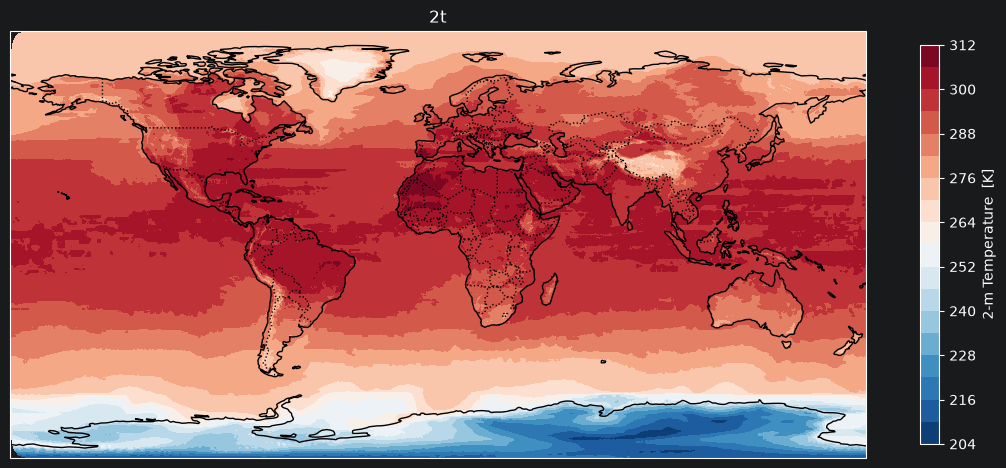

In [64]:
from aifs.plot import plot_field_sequence

fig = plot_field(states[7], "2t")
fig.savefig("t2m.png", dpi=150, bbox_inches="tight")

### Try other variables:

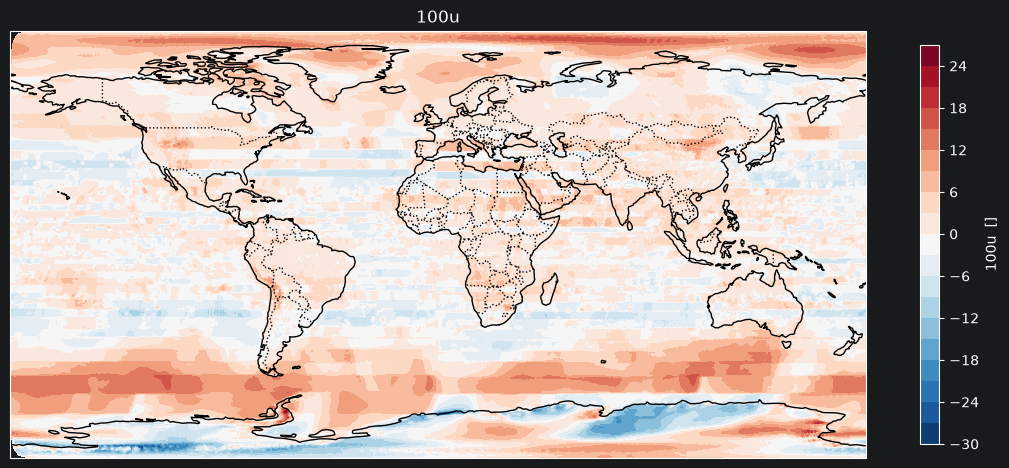

In [62]:
fig = plot_field(states[7], "100u")
fig.savefig("t2m.png", dpi=150, bbox_inches="tight")

## 7. Plot a multi-step sequence


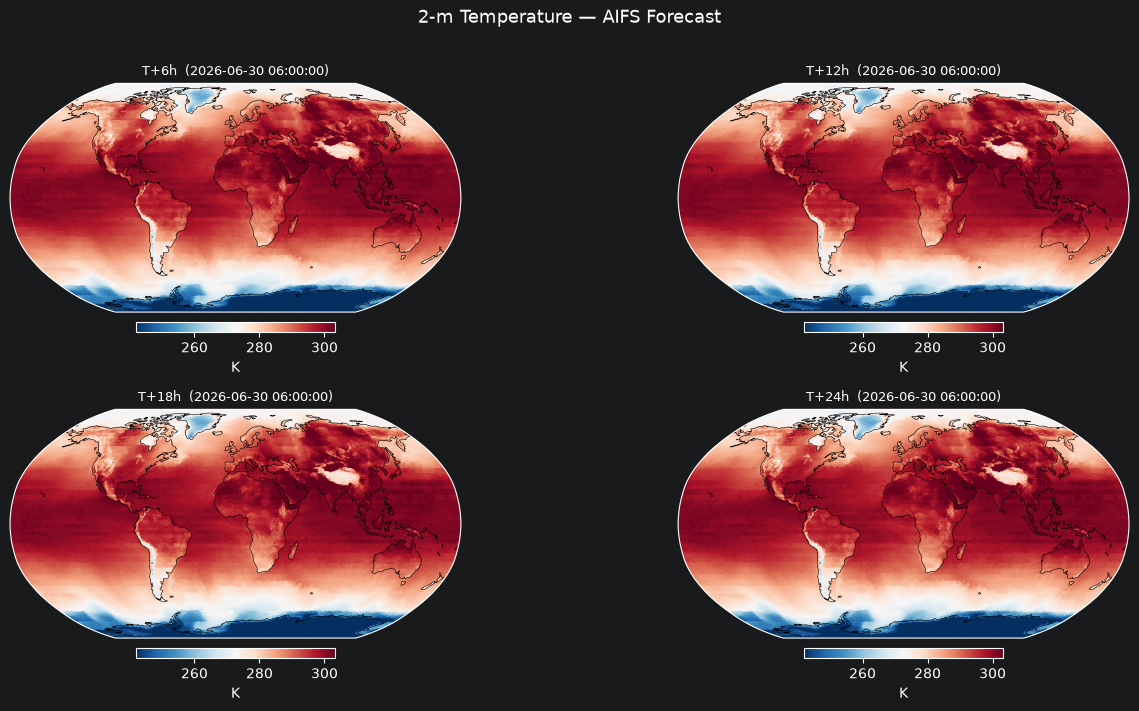

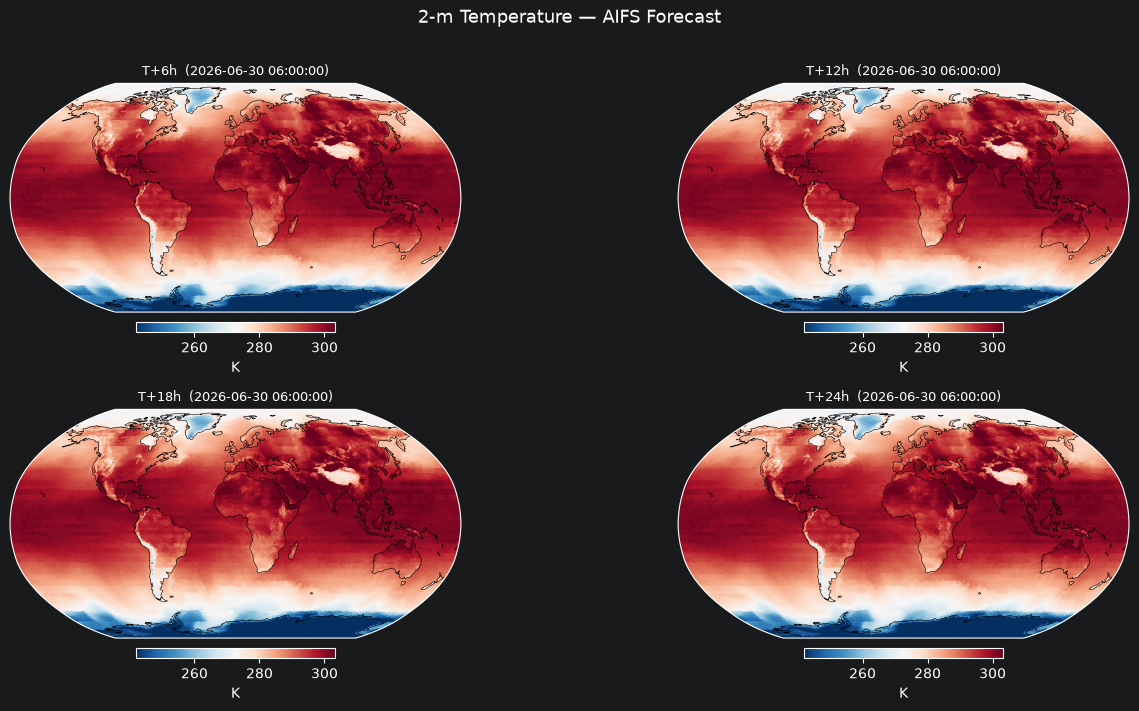

In [7]:
from aifs.plot import plot_field_sequence

fig = plot_field_sequence(states, "2t", max_steps=4, shared_colorscale=True)
fig.savefig("t2m_sequence.png", dpi=150, bbox_inches="tight")
fig


## 8 — Streaming forecast (for long runs / GUIs)

Use `run_forecast_streaming` to process each step as it arrives instead of waiting for the full run to complete.


In [8]:
from aifs.forecast import run_forecast_streaming

for state in run_forecast_streaming(fields, date, lead_time=24):
    t2m_mean = state["fields"]["2t"].mean() - 273.15
    print(f"  {state['date']}  |  global mean T2m = {t2m_mean:.2f} °C")


Fetching 14 files: 100%|██████████| 14/14 [00:00<00:00, 298072.37it/s]
The metadata file 'ai-models.json' is deprecated. New versions of checkpoints will write to 'anemoi.json' instead.
[data] Constant forcings are not supported by this runner.
[data] ['lsm', 'sdor', 'slor', 'wmb', 'z'] must be provided in the input state by the user.
NaNs found in the following variables: ['cdww', 'cos_mwd', 'h1012', 'h1214', 'h1417', 'h1721', 'h2125', 'h2530', 'mwp', 'sin_mwd', 'swh', 'wmb']


  [compat] attn 0.32s  device=mps  ws=1120
  [compat] attn 0.49s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.42s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  2026-06-26 12:00:00  |  global mean T2m = 17.01 °C
  [compat] attn 0.32s  device=mps  ws=1120
  [compat] attn 0.41s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
  [compat] attn 0.40s  device=mps  ws=1120
 

## 9. Saving & reloading forecast output

Forecast states are plain Python dicts with NumPy arrays — save them however you like.


## 10 — Next steps

- **Longer forecasts**: change `lead_time` to 72, 120, 240 hours
- **Regional zoom**: use Cartopy's `set_extent` on the returned figure's axes
- **NetCDF export**: regrid from N320 back to a lat/lon grid with `earthkit-regrid`
  then write with `xarray` + `netCDF4`
- **Gradio demo**: see `app.py` in this repo for a browser-based interface
- **AIFS Ensemble**: swap the checkpoint for `ecmwf/aifs-ens-1.0`

Questions / issues?  Open an issue on the HuggingFace repo.
